# Pacientes con Riesgo — Subtipos por K-Means

Análisis no supervisado: descubrir **subtipos de pacientes dentro de cada enfermedad** (diabetes, paro cardíaco, hipertensión) usando K-Means.

Cada cluster se valida contra:
- **Etiqueta real** (`% positivos` por cluster).
- **Probabilidad media predicha** por el modelo supervisado correspondiente (`models/*_model.joblib`).

K óptimo se elige con **silhouette score** en el rango [2, 6].


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
models_dir = Path("models") if Path("models").exists() else Path("../models")

diabetes_bundle = joblib.load(models_dir / "diabetes_model.joblib")
paro_bundle     = joblib.load(models_dir / "paro_cardiaco_model.joblib")
hiper_bundle    = joblib.load(models_dir / "hipertension_model.joblib")

print("Modelos supervisados cargados:")
print(" - diabetes      :", type(diabetes_bundle["model"]).__name__)
print(" - paro_cardiaco :", type(paro_bundle["model"]).__name__)
print(" - hipertension  :", type(hiper_bundle["model"]).__name__)


Modelos supervisados cargados:
 - diabetes      : RandomForestClassifier
 - paro_cardiaco : LogisticRegression
 - hipertension  : GradientBoostingClassifier


In [3]:
def find_optimal_k(X_scaled, k_range=range(2, 7)):
    scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        scores[k] = silhouette_score(X_scaled, labels)
    return scores

def cluster_and_profile(name, raw_features, y_truth, y_proba, top_features=8):
    """Escala -> elige k por silhouette -> KMeans -> perfila clusters -> PCA 2D."""
    # robustez: solo columnas numéricas
    raw_features = raw_features.select_dtypes(include=np.number).copy()

    scaler = StandardScaler()
    X_s = scaler.fit_transform(raw_features)

    scores = find_optimal_k(X_s)
    k = max(scores, key=scores.get)
    print(f"\n=== {name} ===")
    print(f"Silhouette por k: {{ {', '.join(f'{kk}:{vv:.3f}' for kk,vv in scores.items())} }}")
    print(f"k óptimo = {k}")

    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_s)

    prof = raw_features.copy()
    prof["cluster"]  = labels
    prof["y_truth"]  = y_truth.values
    prof["y_proba"]  = y_proba

    summary = prof.groupby("cluster").agg(
        n=("cluster", "size"),
        pct_positivos=("y_truth", "mean"),
        proba_media_modelo=("y_proba", "mean"),
    ).round(3)
    print("\nResumen por cluster:")
    display(summary)

    global_mean = raw_features.mean()
    cluster_means = prof.groupby("cluster")[raw_features.columns].mean()
    diffs = (cluster_means - global_mean).abs().mean(axis=0).sort_values(ascending=False)
    top = diffs.head(top_features).index.tolist()
    print(f"\nTop {top_features} features que diferencian clusters:")
    display(cluster_means[top].round(2))

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_s)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels, palette="tab10",
                    s=22, alpha=0.7, ax=axes[0], legend="full")
    axes[0].set_title(f"{name} — clusters (PCA)")
    axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
    axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")

    summary[["pct_positivos", "proba_media_modelo"]].plot(
        kind="bar", ax=axes[1], color=["#FF6B6B", "#4C9AFF"]
    )
    axes[1].set_title(f"{name} — riesgo por cluster")
    axes[1].set_ylabel("proporción / probabilidad")
    axes[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()

    return {
        "kmeans": km, "scaler": scaler, "k": int(k),
        "silhouette": float(scores[k]),
        "summary": summary, "cluster_means_top": cluster_means[top],
    }


Cargado: ../data/raw/diabetes.csv  shape=(768, 9)

=== Diabetes ===
Silhouette por k: { 2:0.196, 3:0.195, 4:0.190, 5:0.177, 6:0.168 }
k óptimo = 2

Resumen por cluster:


,n,pct_positivos,proba_media_modelo
cluster,,,
0,351,0.556,0.529
1,417,0.175,0.190



Top 8 features que diferencian clusters:


,Insulin,Glucose,Age,BloodPressure,SkinThickness,BMI,Pregnancies,DiabetesPedigreeFunction
cluster,,,,,,,,
0,168.49,137.91,41.12,78.83,32.74,35.32,5.78,0.51
1,117.25,107.97,26.61,66.96,26.05,30.04,2.22,0.44


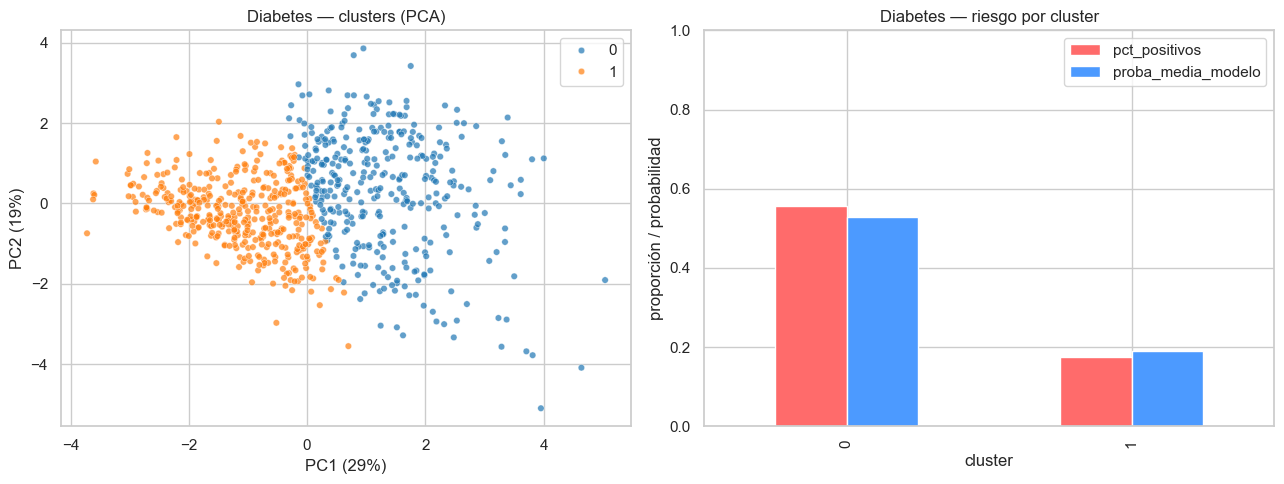

In [4]:
paths = ["Base-de-datos/diabetes.csv", "../Base-de-datos/diabetes.csv", "data/raw/diabetes.csv", "../data/raw/diabetes.csv"]
csv = next((p for p in paths if Path(p).exists()), None)
assert csv, "No encontré diabetes.csv"
df_d = pd.read_csv(csv)
print(f"Cargado: {csv}  shape={df_d.shape}")

# limpieza igual que el supervisado
for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    df_d[c] = df_d[c].replace(0, np.nan)
df_d = df_d.fillna(df_d.median(numeric_only=True))

raw_d   = df_d.drop(columns=["Outcome"])
y_truth = df_d["Outcome"].astype(int)

# recrear binning + one-hot para alimentar el modelo supervisado
df_eng = df_d.copy()
df_eng["BMI_Category"]      = pd.cut(df_eng["BMI"],            bins=[0,18.5,25,30,100],   labels=["Underweight","Normal","Overweight","Obese"])
df_eng["AgeGroup"]          = pd.cut(df_eng["Age"],            bins=[0,30,45,60,120],     labels=["Young","Adult","Middle-aged","Senior"])
df_eng["Glucose_Category"]  = pd.cut(df_eng["Glucose"],        bins=[0,99,125,300],       labels=["Normal","Prediabetes","Diabetes"])
df_eng["Insulin_Category"]  = pd.cut(df_eng["Insulin"],        bins=[0,16,166,1000],      labels=["Low","Normal","High"])
df_eng["BP_Category"]       = pd.cut(df_eng["BloodPressure"],  bins=[0,80,89,200],        labels=["Normal","Elevated","High"])
df_eng = pd.get_dummies(df_eng, columns=["BMI_Category","AgeGroup","Glucose_Category","Insulin_Category","BP_Category"])

expected = diabetes_bundle["metadata"]["feature_columns"]
for c in expected:
    if c not in df_eng.columns:
        df_eng[c] = 0
y_proba = diabetes_bundle["model"].predict_proba(df_eng[expected])[:, 1]

result_d = cluster_and_profile("Diabetes", raw_d, y_truth, y_proba)


Cargado: ../data/raw/Medicaldataset.csv  shape=(1319, 9)

=== Paro cardíaco ===
Silhouette por k: { 2:0.170, 3:0.167, 4:0.186, 5:0.239, 6:0.225 }
k óptimo = 5

Resumen por cluster:


/Users/danielsebastianmaciasmacias/Library/CloudStorage/OneDrive-ITESO/Tu-salud/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,n,pct_positivos,proba_media_modelo
cluster,,,
0,429,0.531,0.526
1,3,0.667,0.923
2,825,0.629,0.623
3,23,0.957,1.000
4,39,1.000,1.000



Top 8 features que diferencian clusters:


,Heart rate,CK-MB,Blood sugar,Diastolic blood pressure,Systolic blood pressure,Age,Troponin,Gender
cluster,,,,,,,,
0,75.69,8.19,143.85,72.61,126.77,58.08,0.15,0.00
1,1111.00,2.62,109.67,95.00,141.00,49.00,0.35,0.33
2,76.01,7.76,147.04,71.97,127.14,55.10,0.27,1.00
3,81.48,5.27,145.70,74.30,133.74,60.52,7.55,0.70
4,75.31,258.94,172.13,71.87,127.28,56.49,0.36,0.72


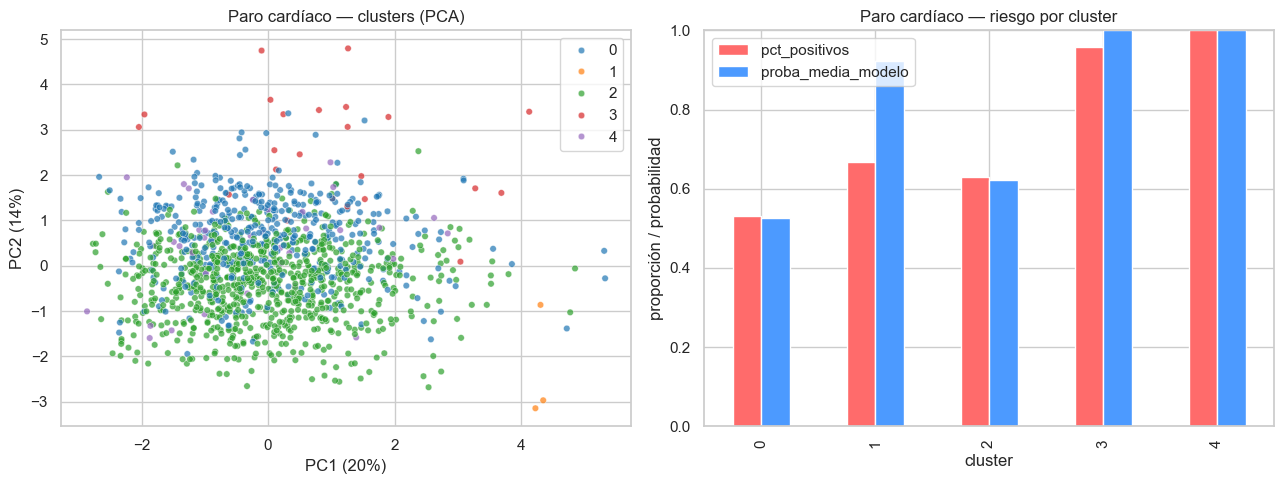

In [5]:
paths = ["Base-de-datos/Medicaldataset.csv", "../Base-de-datos/Medicaldataset.csv", "data/raw/Medicaldataset.csv", "../data/raw/Medicaldataset.csv"]
csv = next((p for p in paths if Path(p).exists()), None)
assert csv, "No encontré Medicaldataset.csv"
df_p = pd.read_csv(csv)
print(f"Cargado: {csv}  shape={df_p.shape}")

df_p["Result"] = (df_p["Result"].astype(str).str.strip().str.lower()
                  .map({"negative": 0, "positive": 1}).astype(int))

raw_p   = df_p.drop(columns=["Result"])
y_truth = df_p["Result"]

X_scaled = paro_bundle["scaler"].transform(raw_p)
y_proba  = paro_bundle["model"].predict_proba(X_scaled)[:, 1]

result_p = cluster_and_profile("Paro cardíaco", raw_p, y_truth, y_proba)


Cargado: ../data/raw/Hipertension_Arterial_Mexico.csv  shape=(4363, 36)

=== Hipertensión ===
Silhouette por k: { 2:0.289, 3:0.289, 4:0.299, 5:0.290, 6:0.119 }
k óptimo = 4

Resumen por cluster:


,n,pct_positivos,proba_media_modelo
cluster,,,
0,2847,0.763,0.763
1,915,0.197,0.198
2,133,0.774,0.767
3,468,0.771,0.768



Top 8 features que diferencian clusters:


,valor_vitamina_bdoce,actividad_total,resultado_glucosa,resultado_glucosa_promedio,valor_trigliceridos,segundamedicion_cintura,medida_cintura,peso
cluster,,,,,,,,
0,171.60,502.88,92.17,104.50,134.19,0.00,88.13,74.51
1,167.00,460.18,93.96,109.40,130.91,91.05,0.08,2.15
2,197.53,374.24,244.42,257.05,256.92,28.55,66.56,49.37
3,445.69,426.57,89.46,105.79,134.41,0.19,82.69,71.92


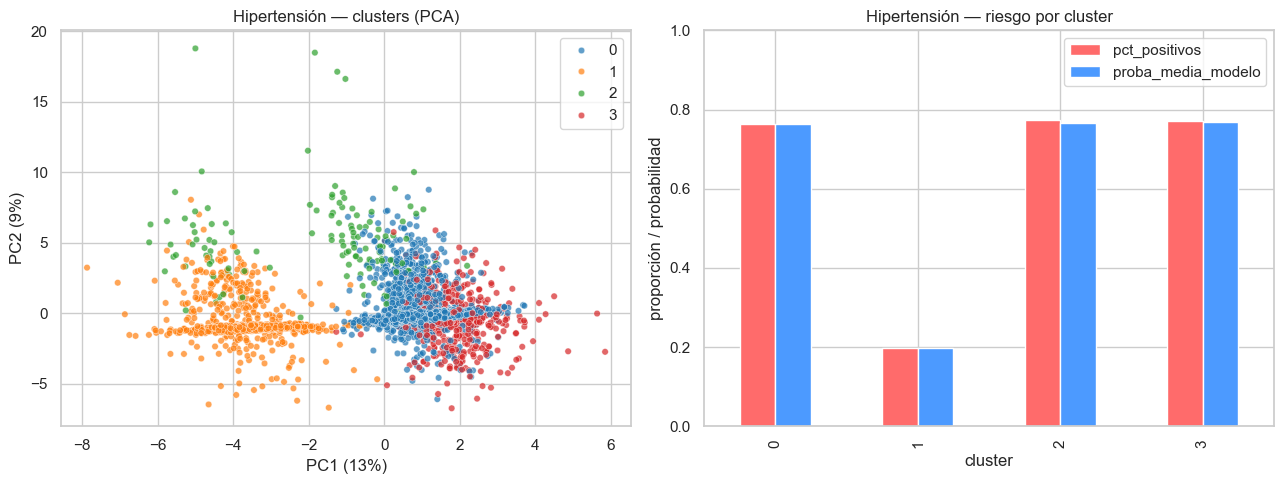

In [6]:
paths = ["data/raw/Hipertension_Arterial_Mexico.csv", "../data/raw/Hipertension_Arterial_Mexico.csv"]
csv = next((p for p in paths if Path(p).exists()), None)
assert csv, "No encontré Hipertension_Arterial_Mexico.csv"
df_h = pd.read_csv(csv)
print(f"Cargado: {csv}  shape={df_h.shape}")

# misma limpieza que el supervisado (incluye FOLIO_I)
id_like = [c for c in df_h.columns if c.lower() in {"id","id_paciente","paciente_id","folio","folio_i"}]
df_h = df_h.drop(columns=id_like)
if "sexo" in df_h.columns and df_h["sexo"].dtype == object:
    mp = {v: i for i, v in enumerate(sorted(df_h["sexo"].dropna().unique()))}
    df_h["sexo"] = df_h["sexo"].map(mp)
df_h = df_h.fillna(df_h.median(numeric_only=True))

raw_h   = df_h.drop(columns=["riesgo_hipertension"])
y_truth = df_h["riesgo_hipertension"].astype(int)

expected = hiper_bundle["metadata"]["feature_columns"]
X_aligned = raw_h[expected]
X_scaled  = hiper_bundle["scaler"].transform(X_aligned)
y_proba   = hiper_bundle["model"].predict_proba(X_scaled)[:, 1]

result_h = cluster_and_profile("Hipertensión", raw_h, y_truth, y_proba)


=== Resumen global de subtipos ===


n  pct_positivos  proba_media_modelo
enfermedad    cluster                                         
diabetes      0         351          0.556               0.529
              1         417          0.175               0.190
paro_cardiaco 0         429          0.531               0.526
              1           3          0.667               0.923
              2         825          0.629               0.623
              3          23          0.957               1.000
              4          39          1.000               1.000
hipertension  0        2847          0.763               0.763
              1         915          0.197               0.198
              2         133          0.774               0.767
              3         468          0.771               0.768

/var/folders/gd/w01c15j92ylb8s4w0fr7vfvm0000gn/T/ipykernel_81809/2882208880.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")


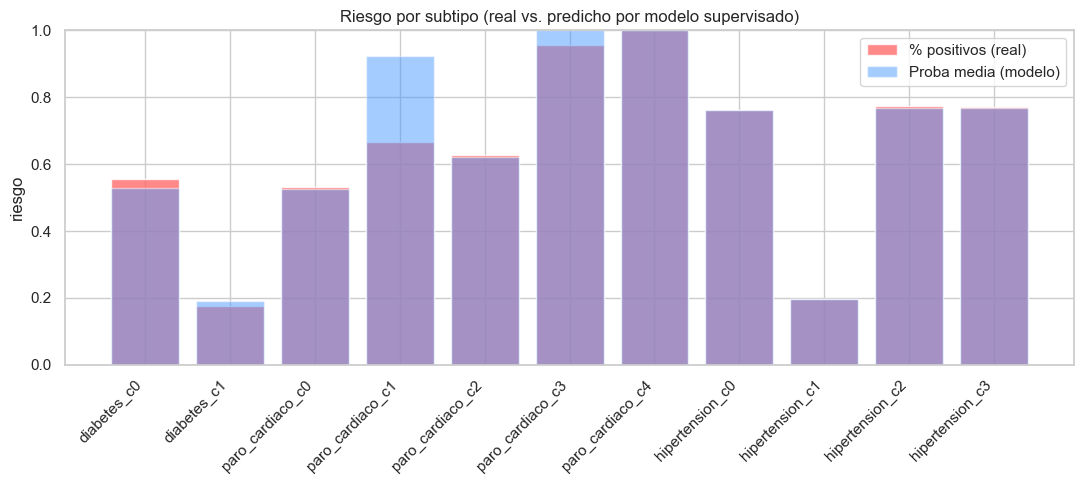

In [7]:
all_summaries = {
    "diabetes":      result_d["summary"],
    "paro_cardiaco": result_p["summary"],
    "hipertension":  result_h["summary"],
}
combined = pd.concat(all_summaries, names=["enfermedad", "cluster"])
print("=== Resumen global de subtipos ===")
display(combined)

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = combined.reset_index()
plot_df["label"] = plot_df["enfermedad"] + "_c" + plot_df["cluster"].astype(str)
ax.bar(plot_df["label"], plot_df["pct_positivos"], color="#FF6B6B", alpha=0.8, label="% positivos (real)")
ax.bar(plot_df["label"], plot_df["proba_media_modelo"], color="#4C9AFF", alpha=0.5, label="Proba media (modelo)")
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("riesgo")
ax.set_title("Riesgo por subtipo (real vs. predicho por modelo supervisado)")
ax.legend()
plt.tight_layout(); plt.show()


In [8]:
artifact = {
    "diabetes":      {"kmeans": result_d["kmeans"], "scaler": result_d["scaler"], "k": result_d["k"], "silhouette": result_d["silhouette"]},
    "paro_cardiaco": {"kmeans": result_p["kmeans"], "scaler": result_p["scaler"], "k": result_p["k"], "silhouette": result_p["silhouette"]},
    "hipertension":  {"kmeans": result_h["kmeans"], "scaler": result_h["scaler"], "k": result_h["k"], "silhouette": result_h["silhouette"]},
}
joblib.dump(artifact, models_dir / "subtipos_kmeans.joblib")

metadata = {
    "approach": "KMeans por enfermedad; k elegido por silhouette en [2,6]",
    "datasets": {
        "diabetes":      {"k": result_d["k"], "silhouette": result_d["silhouette"]},
        "paro_cardiaco": {"k": result_p["k"], "silhouette": result_p["silhouette"]},
        "hipertension":  {"k": result_h["k"], "silhouette": result_h["silhouette"]},
    },
    "summary_per_cluster": {
        name: r["summary"].reset_index().to_dict(orient="records")
        for name, r in [("diabetes", result_d), ("paro_cardiaco", result_p), ("hipertension", result_h)]
    },
}
with open(models_dir / "subtipos_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)

combined.to_csv(models_dir / "subtipos_summary.csv")
print("Guardado:")
print(" -", models_dir / "subtipos_kmeans.joblib")
print(" -", models_dir / "subtipos_metadata.json")
print(" -", models_dir / "subtipos_summary.csv")


Guardado:
 - ../models/subtipos_kmeans.joblib
 - ../models/subtipos_metadata.json
 - ../models/subtipos_summary.csv


## Conclusión

K-Means descubrió subtipos de pacientes **dentro de cada enfermedad**:
- Cada cluster se caracterizó por las features que más lo separan del promedio global.
- Se validó cada cluster contra dos métricas: **% positivos reales** (etiqueta del dataset) y **probabilidad media del modelo supervisado** correspondiente.
- Cuando ambas métricas coinciden alto en un cluster → subgrupo claramente de alto riesgo, candidato a intervención prioritaria.
- Cuando difieren → señal de que el modelo supervisado no captura ese subgrupo, oportunidad para revisar features o reentrenar.

Artefactos en `models/`: `subtipos_kmeans.joblib` (modelos K-Means + scalers), `subtipos_metadata.json`, `subtipos_summary.csv`.
